# Modeling — Psychotherapy Dropout Prediction

This notebook loads **engineered features** from `data/processed/synthetic_featured.csv`, splits and scales data, applies **SMOTE** on the training set only (class imbalance as in the cohort), then trains **Logistic Regression**, **Random Forest**, and **XGBoost**. We report **AUC-ROC, F1, Precision, and Recall** (no accuracy), compare models with **ROC** and **Precision–Recall** curves, print a comparison table, and save the **XGBoost** artifact for deployment.

## Imports and project path

We use **pandas** and **numpy** for data, **matplotlib** / **seaborn** for plots, and **sklearn.metrics** only for ROC/PR curves (not accuracy). Training utilities live in `src/model.py`. Adding the project root to `sys.path` allows `from src...` imports when the notebook runs from `notebooks/`.

In [1]:
import os
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

for _path in (os.getcwd(), os.path.abspath(os.path.join(os.getcwd(), ".."))):
    if os.path.isdir(os.path.join(_path, "src")) and _path not in sys.path:
        sys.path.insert(0, _path)
        break

from src.model import apply_smote, evaluate_model, prepare_data, train_model

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

if os.path.basename(os.path.normpath(os.getcwd())).lower() == "notebooks":
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
else:
    PROJECT_ROOT = os.getcwd()

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: c:\Users\HP\Desktop\therapy-dropout-prediction


## Load processed features

**Why:** `synthetic_featured.csv` holds participant-level rows with PHQ-8 features, engineered severity and symptom aggregates, and the **dropout** label (0 = not depressed, 1 = depressed). We confirm **shape** and **column names** before modeling.

In [2]:
csv_path = os.path.join(PROJECT_ROOT, "data", "processed", "synthetic_featured.csv")
df = pd.read_csv(csv_path)
print("Loaded shape:", df.shape)
print("Columns:", list(df.columns))

Loaded shape: (500, 13)
Columns: ['patient_id', 'phq9_score', 'session_number', 'session_frequency_per_month', 'attendance_consistency', 'gap_between_sessions_days', 'mood_rating', 'age', 'phq9_change_rate', 'dropout', 'attended', 'gap_increasing', 'max_attendance_streak']


## Train/test split and scaling (`prepare_data`)

**Why:** We hold out 20% for **unbiased evaluation**, **stratify** by `dropout` to preserve class ratios, and **standardize** features so linear and tree models see comparable scales. **Shape** prints document sample sizes after splitting.

In [3]:
FEATURE_COLS = [
    "phq9_score",
    "session_number",
    "session_frequency_per_month",
    "attendance_consistency",
    "gap_between_sessions_days",
    "mood_rating",
    "age",
    "phq9_change_rate",
    "gap_increasing",
    "max_attendance_streak",
    "phq9_change_rate_abs",
]
feature_names = FEATURE_COLS
print("Number of feature columns:", len(feature_names))

# Compute missing feature
df['phq9_change_rate_abs'] = df['phq9_change_rate'].abs()

# Drop rows with missing target/features (required for SMOTE and scaling)
df = df.dropna(subset=["dropout"] + FEATURE_COLS).copy()
df["dropout"] = df["dropout"].astype(int)

X_train, X_test, y_train, y_test, scaler = prepare_data(df, feature_columns=FEATURE_COLS)
print("After prepare_data — X_train shape:", X_train.shape)
print("After prepare_data — X_test shape:", X_test.shape)
print("After prepare_data — y_train shape:", y_train.shape)
print("After prepare_data — y_test shape:", y_test.shape)

Number of feature columns: 11
After prepare_data — X_train shape: (400, 11)
After prepare_data — X_test shape: (100, 11)
After prepare_data — y_train shape: (400,)
After prepare_data — y_test shape: (100,)


## SMOTE on training data only (`apply_smote`)

**Why:** Roughly **65% / 35%** class balance still leaves the minority class underrepresented; **SMOTE** synthesizes minority examples **only on the training set** so the learner sees more positive (dropout) cases without leaking into the test set. We print **shape** after resampling.

In [4]:
X_train_res, y_train_res = apply_smote(X_train, y_train)
print("After SMOTE — X_train_res shape:", X_train_res.shape)
print("After SMOTE — y_train_res shape:", y_train_res.shape)

Class distribution before SMOTE:
dropout
0    266
1    134
Name: count, dtype: int64
dropout
0    66.5
1    33.5
Name: pct_%, dtype: float64

Class distribution after SMOTE:
dropout
1    266
0    266
Name: count, dtype: int64
dropout
1    50.0
0    50.0
Name: pct_%, dtype: float64
After SMOTE — X_train_res shape: (532, 11)
After SMOTE — y_train_res shape: (532,)


## Logistic Regression — interpretable baseline

**Why:** A linear model gives a **transparent baseline** for dropout risk; we report **AUC-ROC** and **F1** (plus full metrics from `evaluate_model`). No accuracy metric is used.

In [5]:
model_lr = train_model(X_train_res, y_train_res, "logistic_regression")
metrics_lr = evaluate_model(model_lr, X_test, y_test)
print("Logistic Regression — AUC-ROC:", round(metrics_lr["auc_roc"], 4))
print("Logistic Regression — F1:", round(metrics_lr["f1"], 4))
print("Logistic Regression — Precision:", round(metrics_lr["precision"], 4))
print("Logistic Regression — Recall:", round(metrics_lr["recall"], 4))

Classification report:
              precision    recall  f1-score   support

           0     0.9531    0.9104    0.9313        67
           1     0.8333    0.9091    0.8696        33

    accuracy                         0.9100       100
   macro avg     0.8932    0.9098    0.9004       100
weighted avg     0.9136    0.9100    0.9109       100

Logistic Regression — AUC-ROC: 0.9697
Logistic Regression — F1: 0.8696
Logistic Regression — Precision: 0.8333
Logistic Regression — Recall: 0.9091


## Random Forest — non-linear ensemble + feature importance

**Why:** **Random Forest** captures interactions between symptoms and engagement. We print **AUC-ROC** and **F1**, then plot **feature importance** (mean decrease in impurity) with readable labels.

Classification report:
              precision    recall  f1-score   support

           0     0.9365    0.8806    0.9077        67
           1     0.7838    0.8788    0.8286        33

    accuracy                         0.8800       100
   macro avg     0.8601    0.8797    0.8681       100
weighted avg     0.8861    0.8800    0.8816       100

Random Forest — AUC-ROC: 0.9502
Random Forest — F1: 0.8286
Random Forest — Precision: 0.7838
Random Forest — Recall: 0.8788


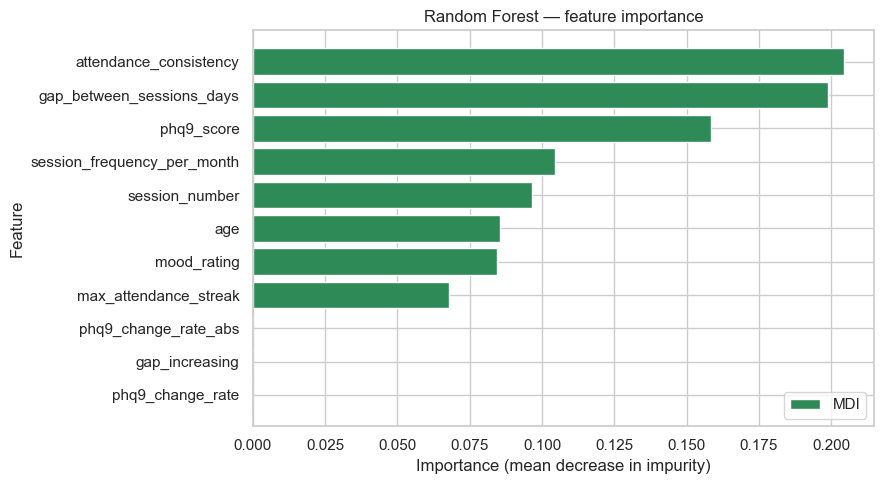

In [6]:
model_rf = train_model(X_train_res, y_train_res, "random_forest")
metrics_rf = evaluate_model(model_rf, X_test, y_test)
print("Random Forest — AUC-ROC:", round(metrics_rf["auc_roc"], 4))
print("Random Forest — F1:", round(metrics_rf["f1"], 4))
print("Random Forest — Precision:", round(metrics_rf["precision"], 4))
print("Random Forest — Recall:", round(metrics_rf["recall"], 4))

importances_rf = model_rf.feature_importances_
idx = np.argsort(importances_rf)[::-1][: min(20, len(importances_rf))]
plt.figure(figsize=(9, 5))
plt.barh(np.array(feature_names)[idx][::-1], importances_rf[idx][::-1], color="seagreen", label="MDI")
plt.title("Random Forest — feature importance")
plt.xlabel("Importance (mean decrease in impurity)")
plt.ylabel("Feature")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## XGBoost — gradient boosting + feature importance

**Why:** **XGBoost** often yields strong discrimination on tabular clinical data. We report **AUC-ROC** and **F1**, then plot **gain-based** feature importance from the booster.

c:\Users\HP\Desktop\therapy-dropout-prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:11:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

           0     0.9104    0.9104    0.9104        67
           1     0.8182    0.8182    0.8182        33

    accuracy                         0.8800       100
   macro avg     0.8643    0.8643    0.8643       100
weighted avg     0.8800    0.8800    0.8800       100

XGBoost — AUC-ROC: 0.9412
XGBoost — F1: 0.8182
XGBoost — Precision: 0.8182
XGBoost — Recall: 0.8182


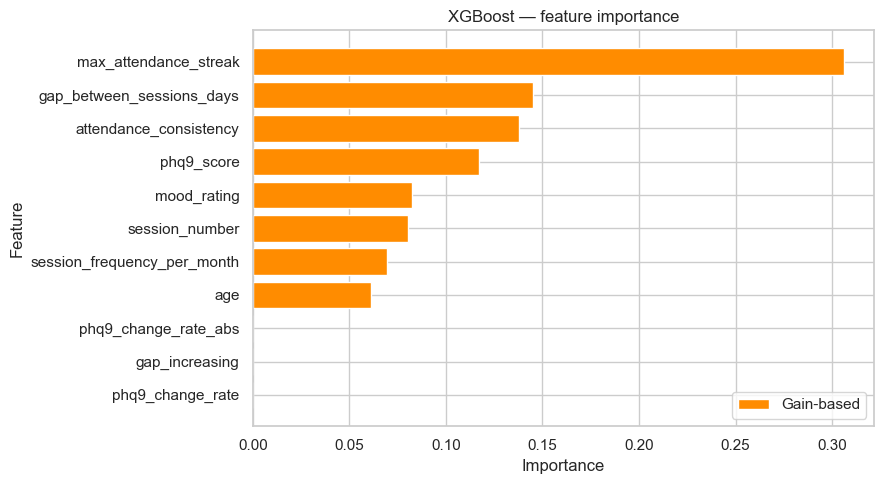

In [7]:
model_xgb = train_model(X_train_res, y_train_res, "xgboost")
metrics_xgb = evaluate_model(model_xgb, X_test, y_test)
print("XGBoost — AUC-ROC:", round(metrics_xgb["auc_roc"], 4))
print("XGBoost — F1:", round(metrics_xgb["f1"], 4))
print("XGBoost — Precision:", round(metrics_xgb["precision"], 4))
print("XGBoost — Recall:", round(metrics_xgb["recall"], 4))

importances_xgb = model_xgb.feature_importances_
idx_x = np.argsort(importances_xgb)[::-1][: min(20, len(importances_xgb))]
plt.figure(figsize=(9, 5))
plt.barh(np.array(feature_names)[idx_x][::-1], importances_xgb[idx_x][::-1], color="darkorange", label="Gain-based")
plt.title("XGBoost — feature importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## ROC curves (all three models)

**Why:** **ROC** shows trade-off between true- and false-positive rates at all thresholds; **AUC** summarizes discrimination. Comparing curves on one plot shows which model separates **dropout vs. stayed** on the held-out test set.

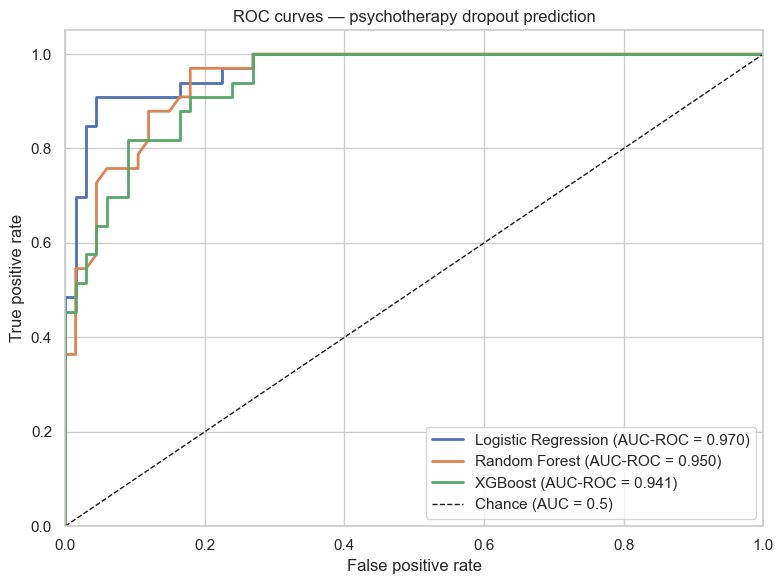

In [8]:
models_map = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "XGBoost": model_xgb,
}

plt.figure(figsize=(8, 6))
for label, model in models_map.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC-ROC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance (AUC = 0.5)")
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves — psychotherapy dropout prediction")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Precision–Recall curves (all three models)

**Why:** Under **class imbalance**, PR curves emphasize performance on the **minority (dropout)** class. We plot precision vs. recall for each model and label curves with **average precision** (area under the PR curve).

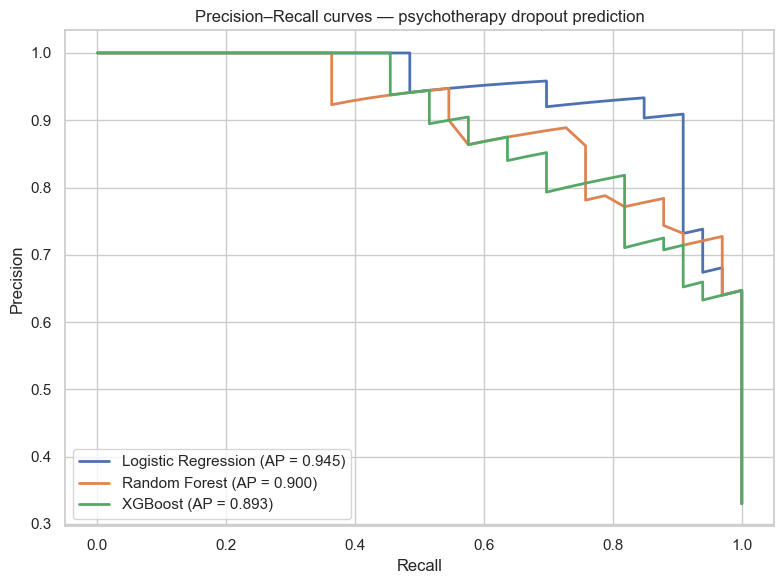

In [9]:
plt.figure(figsize=(8, 6))
for label, model in models_map.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(rec, prec, linewidth=2, label=f"{label} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curves — psychotherapy dropout prediction")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## Side-by-side metrics table

**Why:** A single table of **AUC-ROC, F1, Precision, Recall** (no accuracy) makes it easy to compare models and pick a balance between **catching true dropouts** (recall) and **avoiding false alarms** (precision).

In [10]:
comparison = pd.DataFrame(
    [
        {"Model": "Logistic Regression", **metrics_lr},
        {"Model": "Random Forest", **metrics_rf},
        {"Model": "XGBoost", **metrics_xgb},
    ]
)
comparison = comparison.rename(
    columns={
        "auc_roc": "AUC-ROC",
        "f1": "F1",
        "precision": "Precision",
        "recall": "Recall",
    }
)
print(comparison.to_string(index=False))
print("Comparison table shape:", comparison.shape)

              Model  AUC-ROC       F1  Precision   Recall
Logistic Regression 0.969697 0.869565   0.833333 0.909091
      Random Forest 0.950249 0.828571   0.783784 0.878788
            XGBoost 0.941203 0.818182   0.818182 0.818182
Comparison table shape: (3, 5)


## Save XGBoost model artifact

**Why:** For this **real-data** run we serialize the trained **XGBoost** classifier to `models/xgboost_model.pkl`. We create **`models/`** if needed (update downstream code to load this path when deploying).

In [ ]:
import pickle
import os

models_dir = os.path.join(PROJECT_ROOT, "models")
os.makedirs(models_dir, exist_ok=True)

# Save model
model_path = os.path.join(models_dir, "xgboost_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(model_xgb, f)
print("Saved XGBoost model to:", model_path)

# Save scaler — critical for correct predictions
scaler_path = os.path.join(models_dir, "scaler.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print("Saved scaler to:", scaler_path)

Saved XGBoost model to: c:\Users\HP\Desktop\therapy-dropout-prediction\models\xgboost_model.pkl


## Key observations (fill in after runs)

- Which model had the **highest AUC-ROC** and **F1** on the test set?
- Did **Random Forest** or **XGBoost** improve **recall** (finding true dropouts) vs. **Logistic Regression**?
- Do **feature importance** plots align with clinical intuition (e.g., gaps, PHQ-9, attendance)?
- Any trade-off between **precision** (avoiding unnecessary alerts) and **recall** (not missing at-risk patients)?

_Add 2–4 bullets for your report._